## Google Drive Storage

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
main_path = "/content/drive/MyDrive/AI Models/Tone Detection Model"

## Imports

In [3]:
# Install the safetensors library
!pip install safetensors

In [4]:
import pandas as pd
import pickle
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
from safetensors.tensorflow import save_file
import numpy as np

## Dataset

In [5]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "devkhant24/toxic-comment",
    "jigsaw-toxic-comment-train.csv"
)
# randomly select 50000 rows
df = df.sample(n=220000, random_state=42)

/tmp/ipykernel_3663/2646130499.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 37.3M/37.3M [00:00<00:00, 93.9MB/s]

Extracting zip of jigsaw-toxic-comment-train.csv...


In [6]:
# fillna replaces NaN with ""
texts = df["comment_text"].fillna("")
y = df["toxic"].values

In [7]:
# split into words. count frequency of each word, reduce weight for common words. output to numeric array
# Use the same vectoriser when building prediction APIs
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts).toarray()

In [8]:
pickle.dump(vectorizer, open(f"{main_path}/vectorizer.pkl", "wb"))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# convert to tensor from numpy
# following convention: (features, labels)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [11]:
# prevent model from learning based on data order
train_dataset = train_dataset.shuffle(buffer_size=1000)
# model will learn from batch of 32 each loop
train_dataset = train_dataset.batch(32)
# prepare the next batch in advance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(32)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [12]:
# record number of column
# shape return (rows, column)
input_dim = X_train.shape[1]

## Model

In [13]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(input_dim,)),
        # Expand through matrix multiplication against weight
        tf.keras.layers.Dense(128, activation="relu"),
        # Prevent overfitting, which causes prediction to rely too much on the presence of all data
        # random deactivation
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(32, activation="relu"),
        # linear is perfect for regression model, as it predict any number between 0 - 1
        # classification model is a model that predict class (0 or 1 and so on)
        # whereas regression model's prediction is more so contiuous
        tf.keras.layers.Dense(1, activation="linear"),
    ]
)

In [14]:
# print architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,497 (541.00 KB)

 Trainable params: 138,497 (541.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,  # stop if there is no improvement in 10 epochs
    restore_best_weights=True,  # revert to best epoch
)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"],
)

In [17]:
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=test_dataset,
    verbose=1,
    callbacks=[early_stopping],
)

Epoch 1/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.0506 - mae: 0.1060 - val_loss: 0.0439 - val_mae: 0.1122
Epoch 2/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.0435 - mae: 0.0910 - val_loss: 0.0429 - val_mae: 0.0918
Epoch 3/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 0.0411 - mae: 0.0852 - val_loss: 0.0426 - val_mae: 0.1004
Epoch 4/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.0389 - mae: 0.0804 - val_loss: 0.0433 - val_mae: 0.0937
Epoch 5/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.0364 - mae: 0.0752 - val_loss: 0.0437 - val_mae: 0.0825
Epoch 6/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.0342 - mae: 0.0705 - val_loss: 0.0442 - val_mae: 0.0821
Epoch 7/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.0323 - mae: 0.0666 - val_loss: 0.0445 - val_mae: 0.0815
Epoch 8/50
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.0307 - mae: 0.0632 - val_loss: 0.0448 - val_mae: 0.0767
Epoch 9/50
5500/5500 ━━━━━━━━━━━

In [19]:
# Create a dictionary to store the model's weights
# safetensors typically works with dictionaries of tensors/numpy arrays
weights_dict = {}
for layer in model.layers:
    if layer.weights:
        for weight in layer.weights:
            # Pass the TensorFlow weight directly; safetensors will convert it internally
            weights_dict[weight.name] = weight

# Define the path to save the safetensors file
safetensors_path = f"{main_path}/model_weights.safetensors"

# Save the weights to a safetensors file
save_file(weights_dict, safetensors_path)

print(f"Model weights saved to {safetensors_path}")

Model weights saved to /content/drive/MyDrive/AI Models/Tone Detection Model/model_weights.safetensors


## Evaluate

### Training History Visualization
Let's visualize the training and validation metrics over epochs to understand the model's learning process and identify potential overfitting.

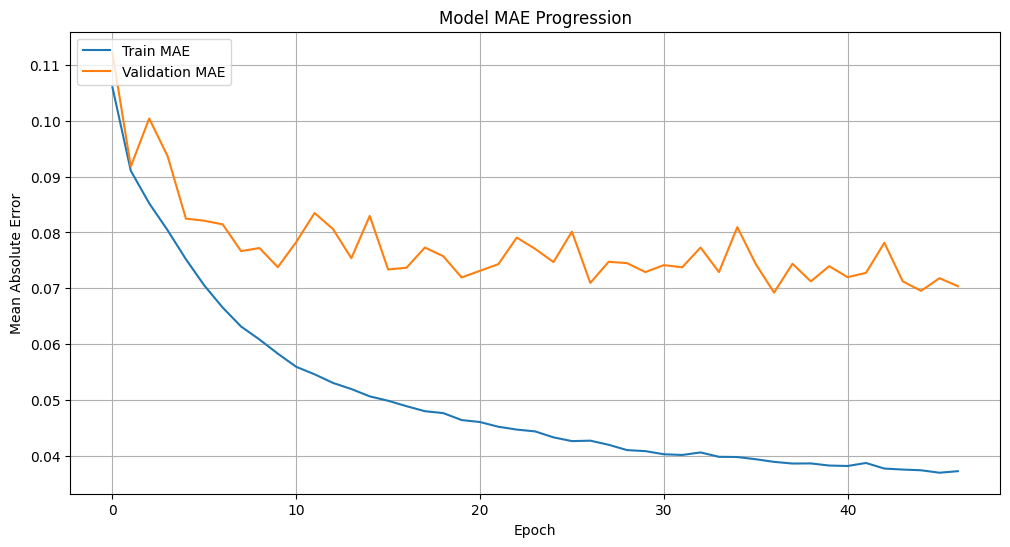

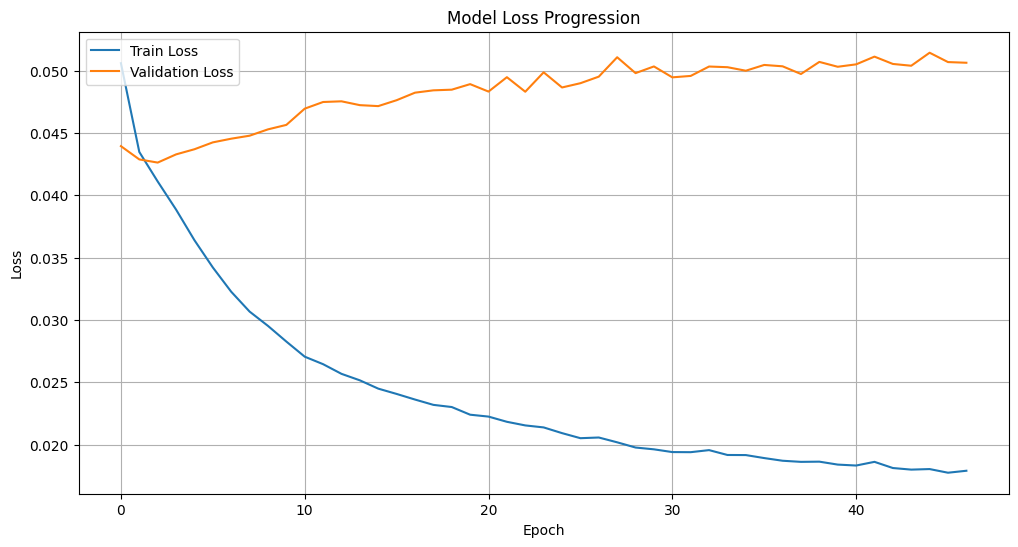

In [20]:
# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Progression')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progression')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### Model Evaluation on Test Data
Now, let's evaluate the trained model on the unseen test dataset to get a final measure of its performance.

In [21]:
loss, mae = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0503 - mae: 0.0692
Test Loss: 0.0503
Test MAE: 0.0692
